In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. Generate data (fewer points + more noise)
np.random.seed(42)
x = np.linspace(0, 10, 30)  # fewer data points
y = 10 * (1 - np.exp(-0.3 * x)) + np.random.normal(0, 2, 30)  # more noise

# reshape
X = x.reshape(-1, 1)

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
def style_plot():
    plt.xlabel("Experience", fontsize=12)
    plt.ylabel("Salary", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)   # remove top box line
    ax.spines['right'].set_visible(False) # remove right box line

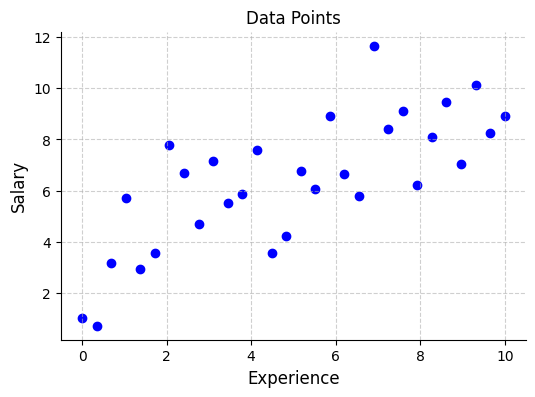

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X, y, color='blue')
plt.title("Data Points")
style_plot()
plt.savefig("data.png", dpi=300)
plt.show()

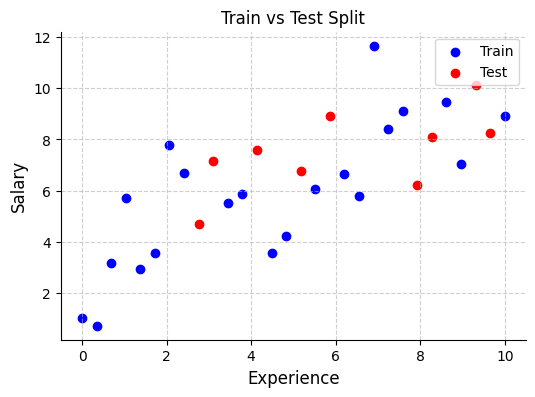

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, color='blue', label="Train")
plt.scatter(X_test, y_test, color='red', label="Test")
plt.legend()
plt.title("Train vs Test Split")
style_plot()
plt.savefig("train_test.png", dpi=300)
plt.show()

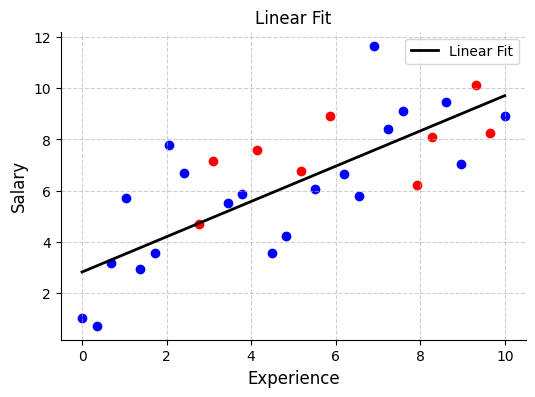

In [ ]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred_lin = lin_reg.predict(X)

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, color='blue')
plt.scatter(X_test, y_test, color='red')
plt.plot(X, y_pred_lin, color='black', linewidth=2, label="Linear Fit")
plt.legend()
plt.title("Linear Fit")
style_plot()
plt.savefig("linear_fit.png", dpi=300)
plt.show()

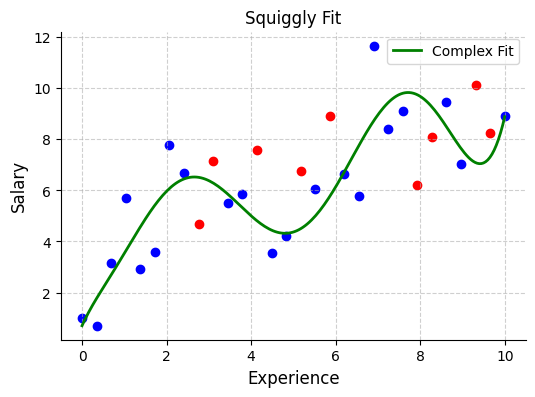

In [ ]:
X_grid = np.linspace(0, 10, 200).reshape(-1, 1)

poly_model = make_pipeline(PolynomialFeatures(8), LinearRegression())
poly_model.fit(X_train, y_train)
y_pred_poly = poly_model.predict(X_grid)

plt.figure(figsize=(6,4))
plt.scatter(X_train, y_train, color='blue')
plt.scatter(X_test, y_test, color='red')
plt.plot(X_grid, y_pred_poly, color='green', linewidth=2, label="Complex Fit")
plt.legend()
plt.title("Squiggly Fit")
style_plot()
plt.savefig("squiggly_fit_fixed.png", dpi=300)
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error

# Linear regression SSR (on training data)
y_pred_lin_train = lin_reg.predict(X_train)
ssr_linear = np.sum((y_train - y_pred_lin_train)**2)

# Polynomial regression SSR (on training data)
y_pred_poly_train = poly_model.predict(X_train)
ssr_poly = np.sum((y_train - y_pred_poly_train)**2)

print("SSR (Linear Fit):", ssr_linear)
print("SSR (Squiggly Fit):", ssr_poly)

SSR (Linear Fit): 67.75054334917587
SSR (Squiggly Fit): 32.83292938164775


In [ ]:
# Test SSR
y_pred_lin_test = lin_reg.predict(X_test)
y_pred_poly_test = poly_model.predict(X_test)

ssr_linear_test = np.sum((y_test - y_pred_lin_test)**2)
ssr_poly_test = np.sum((y_test - y_pred_poly_test)**2)

print("Test SSR (Linear Fit):", ssr_linear_test)
print("Test SSR (Squiggly Fit):", ssr_poly_test)


Test SSR (Linear Fit): 19.630141033146842
Test SSR (Squiggly Fit): 50.75607191921245


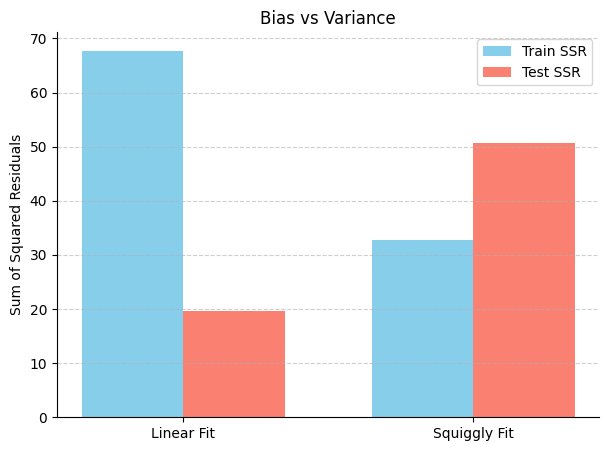

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
labels = ["Linear Fit", "Squiggly Fit"]
train_errors = [ssr_linear, ssr_poly]
test_errors = [ssr_linear_test, ssr_poly_test]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7,5))
plt.bar(x - width/2, train_errors, width, label='Train SSR', color='skyblue')
plt.bar(x + width/2, test_errors, width, label='Test SSR', color='salmon')

plt.ylabel("Sum of Squared Residuals")
plt.title("Bias vs Variance")
plt.xticks(x, labels)
plt.legend()
plt.grid(axis='y', linestyle="--", alpha=0.6)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig("ssr_comparison.png", dpi=300)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.201e+01, tolerance: 1.591e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.370e+01, tolerance: 1.591e-02
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.232e+01, tolerance: 1.591e

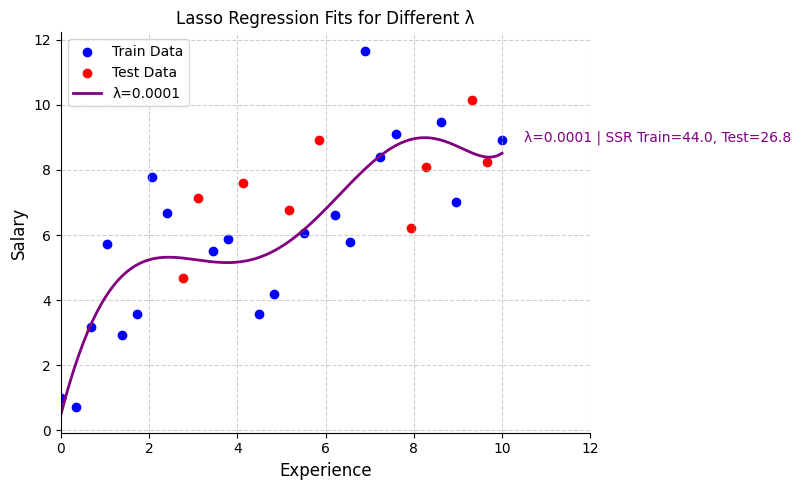

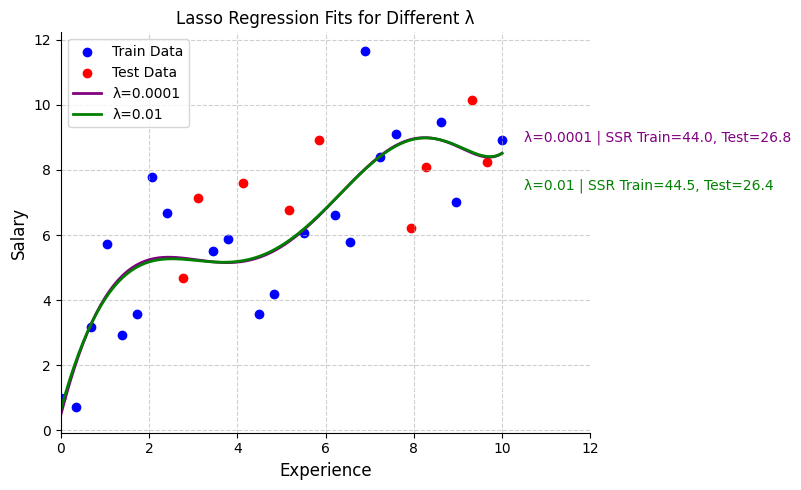

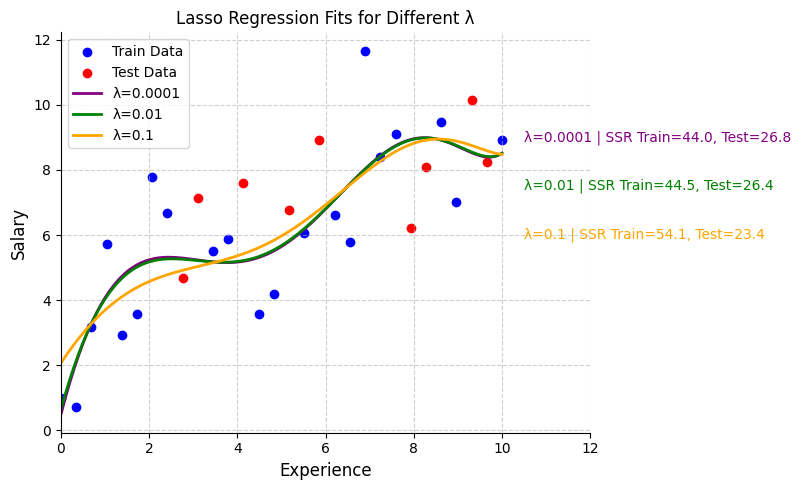

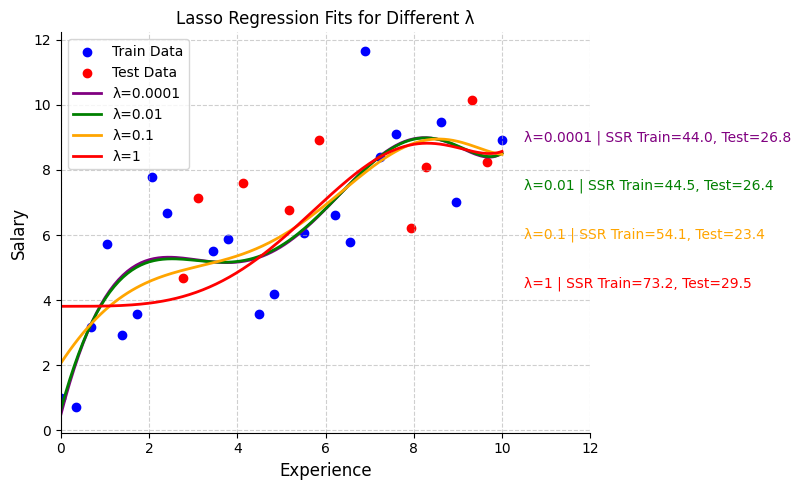

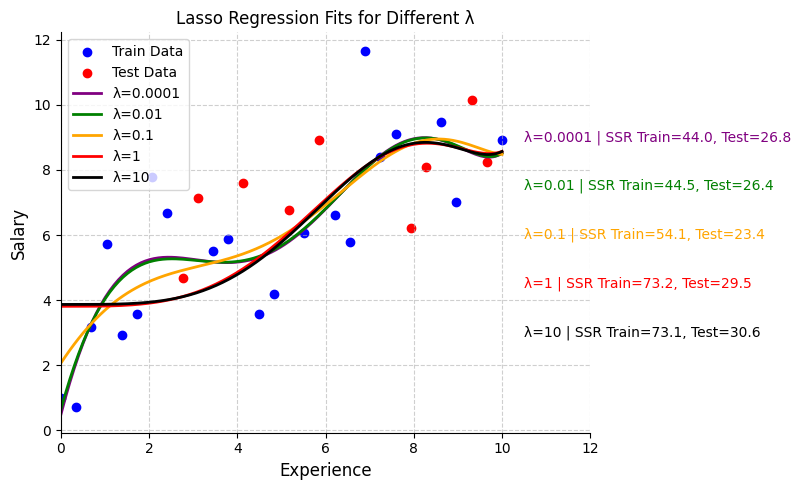

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

np.random.seed(42)
x = np.linspace(0, 10, 30)
y = 10 * (1 - np.exp(-0.3 * x)) + np.random.normal(0, 2, x.shape[0])

X = x.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Helper styling
def style_plot():
    plt.xlabel("Experience", fontsize=12)
    plt.ylabel("Salary", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 2. Define alphas
alphas = [0.0001, 0.01, 0.1, 1, 10]
colors = ["purple", "green", "orange", "red", "black"]

# Grid for smooth curve
X_grid = np.linspace(0, 10, 200).reshape(-1, 1)

# Store curves + SSRs
fits = []

for alpha in alphas:
    lasso_model = make_pipeline(PolynomialFeatures(8), Lasso(alpha=alpha, max_iter=10000))
    lasso_model.fit(X_train, y_train)

    y_pred_grid = lasso_model.predict(X_grid)
    y_pred_train = lasso_model.predict(X_train)
    y_pred_test = lasso_model.predict(X_test)

    ssr_train = np.sum((y_train - y_pred_train)**2)
    ssr_test = np.sum((y_test - y_pred_test)**2)

    fits.append((alpha, y_pred_grid, ssr_train, ssr_test))

# 3. Generate cumulative plots
for i in range(len(fits)):
    plt.figure(figsize=(8,5))

    # Data
    plt.scatter(X_train, y_train, color='blue', label="Train Data")
    plt.scatter(X_test, y_test, color='red', label="Test Data")

    # Add all fits up to i
    for j in range(i+1):
        alpha, y_pred_grid, ssr_train, ssr_test = fits[j]
        plt.plot(X_grid, y_pred_grid, color=colors[j], linewidth=2,
                 label=f"λ={alpha}")

        # Push SSR values outside the plot (x = 10.5 is slightly outside the data range)
        plt.text(10.5, 9 - j*1.5,
                 f"λ={alpha} | SSR Train={ssr_train:.1f}, Test={ssr_test:.1f}",
                 color=colors[j], fontsize=10, va="center")

    plt.title("Lasso Regression Fits for Different λ")
    plt.legend(loc="upper left")
    style_plot()
    plt.xlim(0, 12)  # extend x-axis so text fits nicely
    plt.tight_layout()
    plt.savefig(f"lasso_{i+1}.png", dpi=300, bbox_inches="tight")
    plt.show()



In [ ]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas=np.logspace(-4, 4, 100), cv=5, max_iter=10000)
lasso_cv.fit(X_train, y_train)

best_alpha = lasso_cv.alpha_
print("Best alpha:", best_alpha)

Best alpha: 0.0001


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.032e+01, tolerance: 1.591e-02
  model = cd_fast.enet_coordinate_descent(


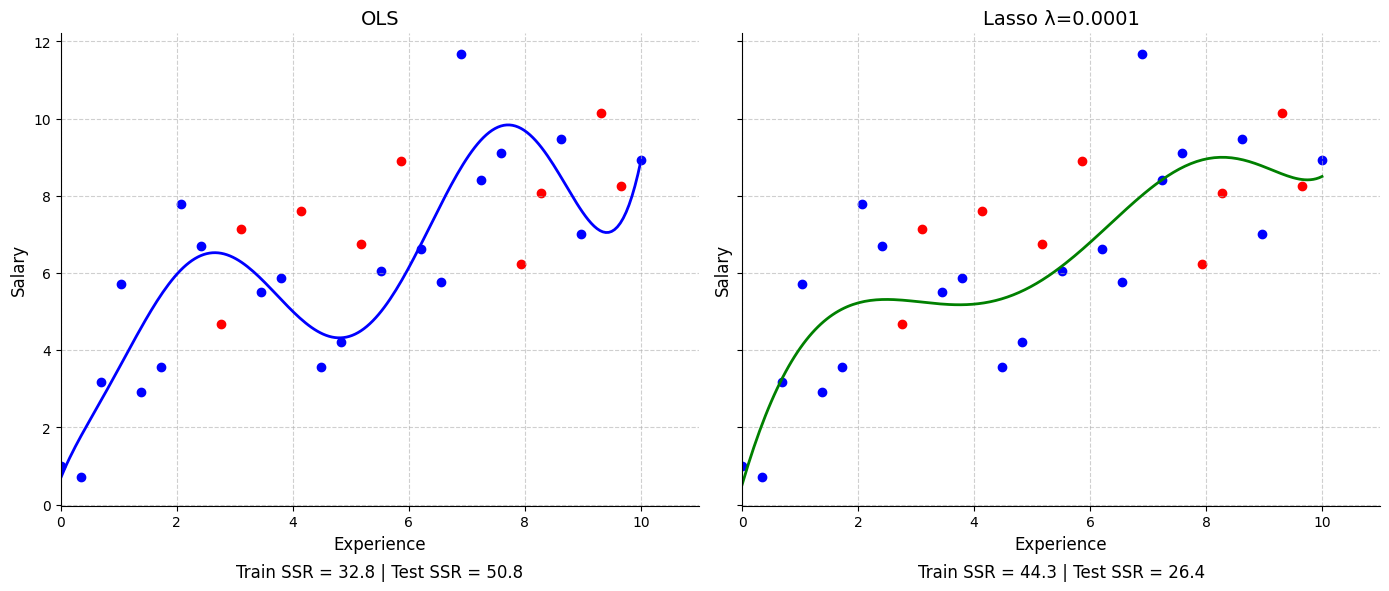

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Generate data
np.random.seed(42)
x = np.linspace(0, 10, 30)
y = 10 * (1 - np.exp(-0.3 * x)) + np.random.normal(0, 2, x.shape[0])

X = x.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Helper styling
def style_plot(ax):
    ax.set_xlabel("Experience", fontsize=12)
    ax.set_ylabel("Salary", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.6)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 2. Grid for smooth curve
X_grid = np.linspace(0, 10, 200).reshape(-1, 1)

# 3. Define models
ols_model = make_pipeline(PolynomialFeatures(8), LinearRegression())  # no scaler for consistency
lasso_model = make_pipeline(PolynomialFeatures(8), StandardScaler(),
                            Lasso(alpha=0.0001, max_iter=10000, random_state=42))

models = [("OLS", ols_model, "blue"), ("Lasso λ=0.0001", lasso_model, "green")]

# 4. Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, (name, model, color) in zip(axes, models):
    model.fit(X_train, y_train)

    # Predictions
    y_pred_grid = model.predict(X_grid)
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)

    # SSRs
    ssr_train = np.sum((y_train - y_pred_train)**2)
    ssr_test = np.sum((y_test - y_pred_test)**2)

    # Scatter + line
    ax.scatter(X_train, y_train, color='blue', label="Train Data")
    ax.scatter(X_test, y_test, color='red', label="Test Data")
    ax.plot(X_grid, y_pred_grid, color=color, linewidth=2, label=name)

    # Title + style
    ax.set_title(name, fontsize=14)
    style_plot(ax)
    ax.set_xlim(0, 11)

    # SSR text below each subplot
    ax.text(0.5, -0.15, f"Train SSR = {ssr_train:.1f} | Test SSR = {ssr_test:.1f}",
            transform=ax.transAxes, fontsize=12, color="black", ha="center")

plt.tight_layout()
plt.savefig("ols_vs_lasso_fixed.png", dpi=300, bbox_inches="tight")
plt.show()


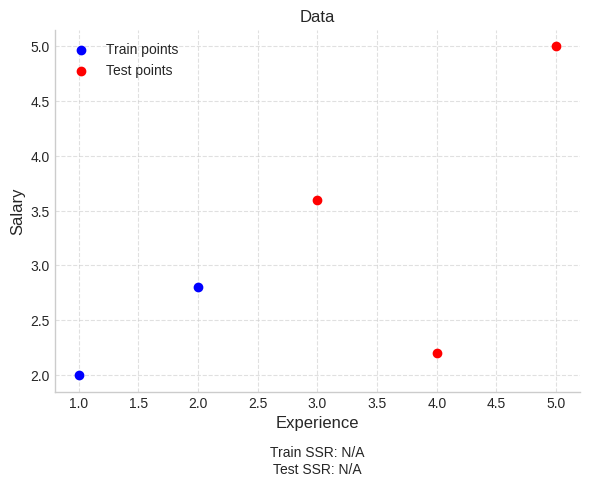

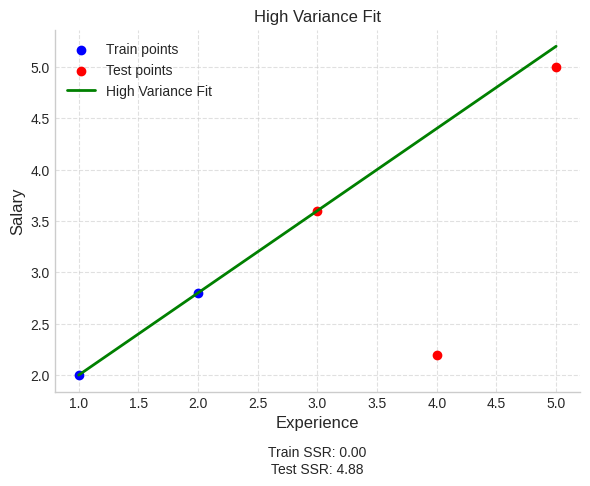

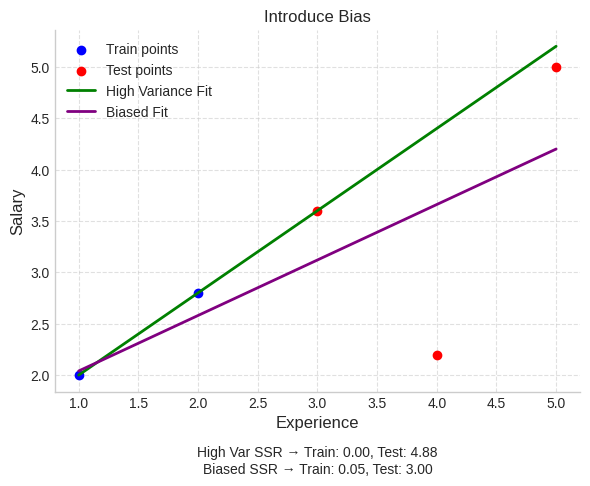

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Style function
def style_plot():
    plt.xlabel("Experience", fontsize=12)
    plt.ylabel("Salary", fontsize=12)
    plt.grid(True, linestyle="--", alpha=0.6)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Generate data
X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
y = np.array([2.0, 2.8, 3.6, 2.2, 5.0])

# Train/test split manually
X_train, y_train = X[:2], y[:2]   # first 2 points for training
X_test, y_test = X[2:], y[2:]     # rest 3 for testing

# -------- Model 1: High variance (exact fit to 2 train points) -------- #
model_high_var = LinearRegression()
model_high_var.fit(X_train, y_train)
y_pred_train1 = model_high_var.predict(X_train)
y_pred_test1 = model_high_var.predict(X_test)
ssr_train1 = np.sum((y_train - y_pred_train1) ** 2)
ssr_test1 = np.sum((y_test - y_pred_test1) ** 2)

# -------- Model 2: Biased fit (use all 5 points) -------- #
model_biased = LinearRegression()
model_biased.fit(X, y)
y_pred_train2 = model_biased.predict(X_train)
y_pred_test2 = model_biased.predict(X_test)
ssr_train2 = np.sum((y_train - y_pred_train2) ** 2)
ssr_test2 = np.sum((y_test - y_pred_test2) ** 2)

# ========== Frame 1: Only points ========== #
plt.figure(figsize=(6, 5))
plt.scatter(X_train, y_train, color="blue", label="Train points")
plt.scatter(X_test, y_test, color="red", label="Test points")
plt.legend()
style_plot()
plt.title("Data")
plt.text(0.5, -0.15, "Train SSR: N/A\nTest SSR: N/A",
         ha="center", va="top", transform=plt.gca().transAxes)
plt.tight_layout()
plt.savefig("data_points.png",dpi=300, bbox_inches="tight")
plt.show()

# ========== Frame 2: Add high variance line ========== #
plt.figure(figsize=(6, 5))
plt.scatter(X_train, y_train, color="blue", label="Train points")
plt.scatter(X_test, y_test, color="red", label="Test points")
plt.plot(X, model_high_var.predict(X), color="green", linewidth=2, label="High Variance Fit")
plt.legend()
style_plot()
plt.title("High Variance Fit")
plt.text(0.5, -0.15, f"Train SSR: {ssr_train1:.2f}\nTest SSR: {ssr_test1:.2f}",
         ha="center", va="top", transform=plt.gca().transAxes)
plt.tight_layout()
plt.savefig("high_variance.png",dpi=300, bbox_inches="tight")
plt.show()

# ========== Frame 3: Add biased line while retaining high variance line ========== #
plt.figure(figsize=(6, 5))
plt.scatter(X_train, y_train, color="blue", label="Train points")
plt.scatter(X_test, y_test, color="red", label="Test points")
plt.plot(X, model_high_var.predict(X), color="green", linewidth=2, label="High Variance Fit")
plt.plot(X, model_biased.predict(X), color="purple", linewidth=2, label="Biased Fit")
plt.legend()
style_plot()
plt.title("Introduce Bias")
plt.text(0.5, -0.15,
         f"High Var SSR → Train: {ssr_train1:.2f}, Test: {ssr_test1:.2f}\n"
         f"Biased SSR → Train: {ssr_train2:.2f}, Test: {ssr_test2:.2f}",
         ha="center", va="top", transform=plt.gca().transAxes)
plt.tight_layout()
plt.savefig("introduce_bias.png",dpi=300, bbox_inches="tight")
plt.show()


In [5]:
from sklearn.datasets import load_diabetes

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

from sklearn.model_selection import train_test_split

In [11]:
data = load_diabetes()

df = pd.DataFrame(data.data,columns=data.feature_names)
df['TARGET'] = data.target

df_head_15 = df.head(15)

# Export to Excel (and download)
df_head_15.to_excel('diabetes_data_15_rows.xlsx', index=False)
from google.colab import files
files.download('diabetes_data_15_rows.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
X_train,X_test,y_train,y_test = train_test_split(data.data,data.target,test_size=0.2,random_state=2)

In [13]:
coefs = []
r2_scores = []

for i in [0,0.1,1,10]:
    reg = Lasso(alpha=i)
    reg.fit(X_train,y_train)

    coefs.append(reg.coef_.tolist())
    y_pred = reg.predict(X_test)
    r2_scores.append(r2_score(y_test,y_pred))

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.967e+05, tolerance: 2.124e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

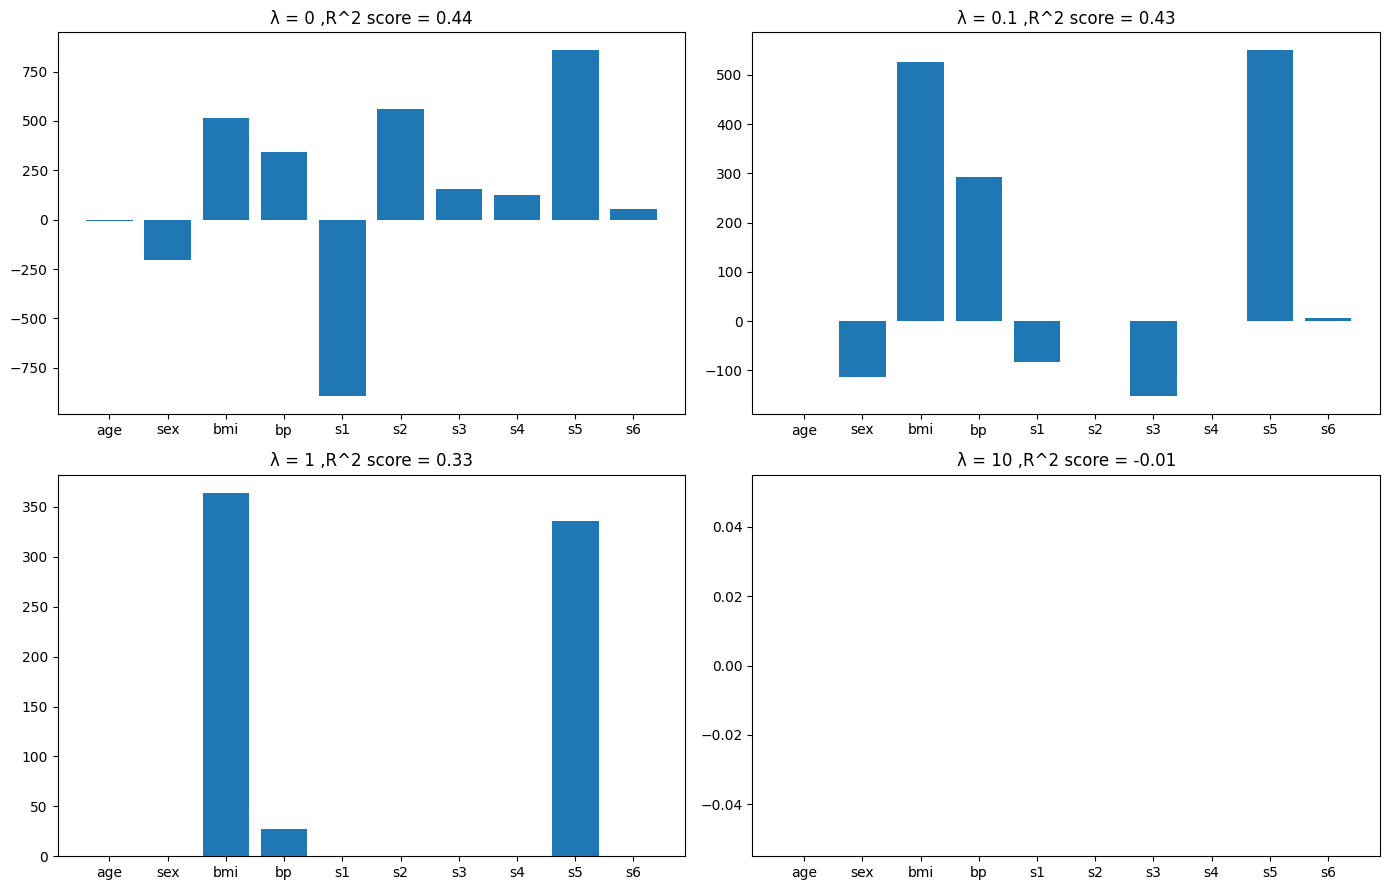

In [15]:
plt.figure(figsize=(14,9))
plt.subplot(221)
plt.bar(data.feature_names,coefs[0])
plt.title('λ = 0 ,R^2 score = {}'.format(round(r2_scores[0],2)))

plt.subplot(222)
plt.bar(data.feature_names,coefs[1])
plt.title('λ = 0.1 ,R^2 score = {}'.format(round(r2_scores[1],2)))

plt.subplot(223)
plt.bar(data.feature_names,coefs[2])
plt.title('λ = 1 ,R^2 score = {}'.format(round(r2_scores[2],2)))

plt.subplot(224)
plt.bar(data.feature_names,coefs[3])
plt.title('λ = 10 ,R^2 score = {}'.format(round(r2_scores[3],2)))

plt.tight_layout()
plt.savefig("lasso_coefs.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
alphas = [0,0.0001,0.001,0.01,0.1,1,10,100,1000,10000]

coefs = []

for i in alphas:
    reg = Lasso(alpha=i)
    reg.fit(X_train,y_train)

    coefs.append(reg.coef_.tolist())

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.967e+05, tolerance: 2.124e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

In [20]:
input_array = np.array(coefs)
coef_df = pd.DataFrame(input_array, columns=data.feature_names)
coef_df['alpha'] = alphas
coef_df = coef_df.set_index('alpha')  # Set index and reassign

# Export to Excel
coef_df.to_excel('coefficients_data.xlsx')

# Download the file (in Colab)
from google.colab import files
files.download('coefficients_data.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
alphas = [0,0.0001,0.0005,0.001,0.005,0.1,0.5,1,5,10]

coefs = []

for i in alphas:
    reg = Lasso(alpha=i)
    reg.fit(X_train,y_train)

    coefs.append(reg.coef_.tolist())

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.967e+05, tolerance: 2.124e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

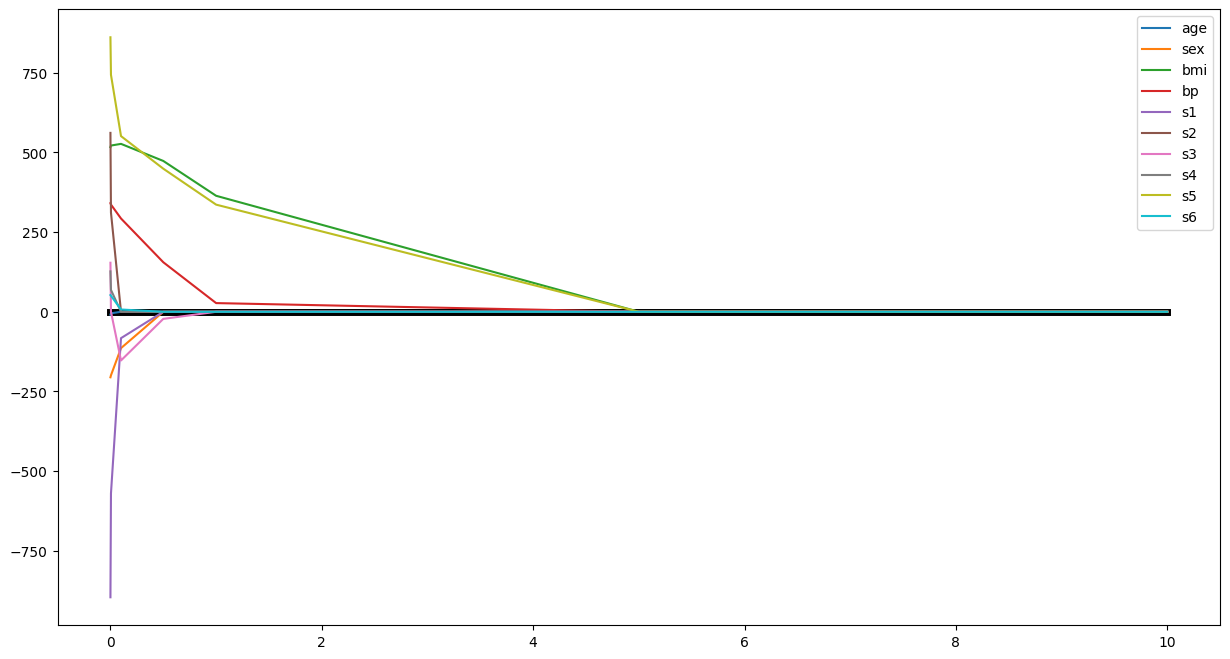

In [19]:
input_array = np.array(coefs).T

plt.figure(figsize=(15,8))
plt.plot(alphas,np.zeros(len(alphas)),color='black',linewidth=5)
for i in range(input_array.shape[0]):
    plt.plot(alphas,input_array[i],label=data.feature_names[i])
plt.legend()
plt.savefig("high_coefficients.png", dpi=300, bbox_inches="tight")
plt.show()